In [ ]:
To create a cosmic transfer function, a common and well-established fitting formula is that of Eisenstein & Hu (1998) for a universe with cold dark matter (CDM) and baryons, including the effects of baryon acoustic oscillations (BAOs). This formula is analytically expressed and provides a good balance of accuracy and computational efficiency compared to running full Boltzmann codes like CAMB or CLASS.

The provided cosmological parameters are:
*   `h = 0.675` (Hubble parameter)
*   `Omega_m = 0.31` (Total matter density parameter)
*   `Omega_b = 0.0487` (Baryonic matter density parameter)
*   `sigma_8 = 0.83` (Amplitude of matter fluctuations, not used for *shape* of T(k), but for power spectrum normalization)
*   `n_s = 0.96` (Primordial spectral index, not used for *shape* of T(k), but for power spectrum slope)

The transfer function `T(k)` describes how the primordial power spectrum of density fluctuations is modified as the universe expands and evolves. It's usually normalized such that `T(k -> 0) = 1`.

Below is a Python implementation of the Eisenstein & Hu (1998) transfer function, carefully following their original paper (ApJ 496, 605-614) and common adaptations in cosmological codes.

```python
import numpy as np

def eh98_transfer_function(k_in_mpc_inv, h, Omega_m, Omega_b, T_CMB=2.7255, N_eff=3.046):
    """
    Calculates the cosmic transfer function using the Eisenstein & Hu (1998)
    fitting formula, including baryonic oscillations.

    This implementation closely follows the formulas in Eisenstein & Hu (1998),
    "A Fitting Formula for the Transfer Function of Baryonic Matter and Cold Dark Matter"
    (ApJ 496, 605-614).

    Parameters
    ----------
    k_in_mpc_inv : array_like
        Wavenumbers in units of 1/Mpc.
    h : float
        Hubble parameter: H_0 / (100 km/s/Mpc).
    Omega_m : float
        Total matter density parameter at z=0.
    Omega_b : float
        Baryonic matter density parameter at z=0.
    T_CMB : float, optional
        CMB temperature in Kelvin. Default is 2.7255 K.
    N_eff : float, optional
        Effective number of relativistic species. Default is 3.046.

    Returns
    -------
    T_k : array_like
        The transfer function T(k) for the input wavenumbers, normalized to 1
        at k -> 0.

    Notes
    -----
    The Eisenstein & Hu (1998) paper uses a mix of units for k (Mpc^-1 and h/Mpc).
    This implementation converts input k (Mpc^-1) to k_h (h/Mpc) internally
    as needed to match the paper's conventions for specific formulas.
    """
    k_in_mpc_inv = np.atleast_1d(k_in_mpc_inv)
    k_h = k_in_mpc_inv / h  # Convert k to h/Mpc for internal calculations where specified in EH98

    # Derived cosmological parameters (physical densities)
    omega_b = Omega_b * h**2
    omega_c = (Omega_m - Omega_b) * h**2
    omega_m = Omega_m * h**2
    theta_cmb = T_CMB / 2.7255  # Ratio of CMB temperature to fiducial value

    # --- 1. Key Epochs and Scales ---

    # Eq. 2: z_eq (redshift of matter-radiation equality)
    z_eq = 2.50e4 * omega_m * theta_cmb**(-4)

    # Eq. 3: R(z) (ratio of baryon-photon momentum density)
    # R(z) = 3.15e4 * omega_b * theta_cmb**(-4) / (1 + z)
    # R_eq = R(z_eq)
    R_z = lambda z: 3.15e4 * omega_b * theta_cmb**(-4) / (1.0 + z)
    R_eq = R_z(z_eq)

    # Eq. 4: z_drag (redshift of drag epoch, baryon decoupling)
    b1 = 0.313 * omega_m**(-0.419) * (1 + 0.607 * omega_m**0.674)
    b2 = 0.238 * omega_m**0.223 * (1 + 0.607 * omega_m**0.674)
    z_drag = 1291. * omega_m**0.251 / (1. + 0.659 * omega_m**0.828) * (1. + b1 * omega_b**b2)

    # Eq. 5: R_drag = R(z_drag)
    R_drag = R_z(z_drag)

    # Eq. 6: s (sound horizon at drag epoch, in Mpc)
    # k_eq_mpc_inv is k_eq in Mpc^-1, not h/Mpc, for use with s.
    k_eq_mpc_inv = 0.0746 * omega_m
    s_val = 2. / (3. * k_eq_mpc_inv) * np.sqrt(6. / R_eq) * \
            np.log((np.sqrt(1. + R_drag) + np.sqrt(R_drag + R_eq)) / (1. + np.sqrt(R_eq)))

    # Eq. 7: alpha_nu_cdm (neutrino density correction for CDM)
    alpha_nu_cdm = 1.0 - 0.328 * np.log(431.0 * omega_m) * (N_eff / 3.046)**0.75 * \
                   (0.0107 * theta_cmb**4) / omega_m

    # Eq. 8: k_silk_h (silk damping scale, in h/Mpc)
    k_silk_h = 1.6 * omega_b**0.52 * omega_m**0.73 * (1. + (10.4 * omega_m)**(-0.95))

    # --- 2. Components of the Transfer Function (T_c for CDM, T_b for Baryons) ---
    # The final transfer function is a weighted sum: T(k) = (Omega_b/Omega_m) * T_b(k) + (Omega_c/Omega_m) * T_c(k)
    # Each T_b and T_c themselves are modified versions of a base T_0 function.

    # --- CDM Transfer Function (T_c, from EH98 Section 3.1.1 & 3.2, Eqs. 19, 20, 22, 23) ---

    # Eq. 22: alpha_c (effective alpha for CDM, depends on f_b, f_c)
    f_b_eh = Omega_b / Omega_m
    f_c_eh = (Omega_m - Omega_b) / Omega_m
    alpha_c_term = alpha_nu_cdm * f_c_eh + \
                   f_b_eh * alpha_nu_cdm * \
                   (1.0 - 0.553 * f_b_eh + 0.126 * f_b_eh**2) * \
                   (1.0 / (1.0 + (0.5 * k_eq_mpc_inv * s_val)**2))

    # Eq. 19: Gamma_eff_c for CDM
    Gamma_eff_c = omega_m * (alpha_c_term + (1.0 - alpha_c_term) / (1.0 + (0.43 * k_h * s_val)**4))

    # Eq. 20: q_c for CDM (normalized wavenumber)
    q_c_eh = k_h / Gamma_eff_c

    # Base transfer function L_0(q), C_0(q) for CDM (based on Eq. 27/29)
    L_0_c_eh = np.log(np.exp(1) + 1.8 * q_c_eh)
    C_0_c_eh = 14.2 + 735. / (1.0 + 617. * q_c_eh**2)
    T_c_base = L_0_c_eh / (L_0_c_eh + C_0_c_eh * q_c_eh**2)

    # Eq. 23: beta_c (damping factor for CDM at small scales)
    beta_c_damping = 1.0 / (1.0 + (0.84 * omega_c**0.5 * h)**(1.0/3.0))

    # Final T_c(k) (Eq. 20, multiplied by damping term as suggested in text)
    T_c_k = T_c_base * (1.0 + (k_h * s_val / 5.4)**4)**(-beta_c_damping)


    # --- Baryon Transfer Function (T_b, from EH98 Section 3.1.2 & 3.2, Eqs. 21, 24, 25) ---

    # Eq. 24: alpha_b (effective alpha for baryons)
    alpha_b_term = (2.07 * R_eq**(-0.707) * (1.0 + 0.353 * R_eq**0.707)) * \
                   (1.0 + (4.0 / (3.0 * R_eq))**0.84) * (N_eff / 3.046)**0.2
    alpha_b_term *= alpha_nu_cdm

    # Eq. 19: Gamma_eff_b for Baryons
    Gamma_eff_b = omega_m * (alpha_b_term + (1.0 - alpha_b_term) / (1.0 + (0.43 * k_h * s_val)**4))

    # Eq. 21: q_b for Baryons (normalized wavenumber)
    q_b_eh = k_h / Gamma_eff_b

    # Base transfer function L_0(q), C_0(q) for Baryons (based on Eq. 27/29)
    L_0_b_eh = np.log(np.exp(1) + 1.8 * q_b_eh)
    C_0_b_eh = 14.2 + 735. / (1.0 + 617. * q_b_eh**2)
    T_b_base = L_0_b_eh / (L_0_b_eh + C_0_b_eh * q_b_eh**2)

    # Baryonic wiggle part and damping (from Eq. 21 and 25)
    # F_s factor controls amplitude of wiggles
    F_s = 1.0 / (1.0 + (k_h * s_val / 5.4)**2)

    # Damping for baryons (Eq. 25)
    beta_b_damping = 1.0 / (1.0 + (k_silk_h / k_h)**2)

    # Final T_b(k) (Eq. 21, combining base, wiggle and damping terms)
    # j_0(x) = sin(x)/x. Handle k_h * s_val == 0 case for j_0.
    x_j0 = k_h * s_val
    j_0_x = np.sin(x_j0) / x_j0
    j_0_x[x_j0 == 0] = 1.0 # sin(x)/x -> 1 as x -> 0

    T_b_k = T_b_base * (F_s * j_0_x + (1.0 - F_s) * np.cos(k_h * s_val)) * beta_b_damping

    # --- 3. Combined Transfer Function (Eq. 28) ---
    T_k = (Omega_b / Omega_m) * T_b_k + (Omega_m - Omega_b) / Omega_m * T_c_k

    return T_k

# --- Example Usage ---
if __name__ == "__main__":
    # Given cosmological parameters
    h = 0.675
    Omega_m = 0.31
    Omega_b = 0.0487
    # sigma_8 and n_s are for power spectrum normalization/tilt, not transfer function shape
    # sigma_8 = 0.83
    # n_s = 0.96

    # Wavenumbers (k) in 1/Mpc
    k_values = np.logspace(-4, 1, 500) # From 10^-4 to 10^1 Mpc^-1

    # Calculate the transfer function
    T_k_eh98 = eh98_transfer_function(k_values, h, Omega_m, Omega_b)

    print(f"Calculated transfer function for k = {k_values[0]:.2e} 1/Mpc: T(k) = {T_k_eh98[0]:.4f}")
    print(f"Calculated transfer function for k = {k_values[100]:.2e} 1/Mpc: T(k) = {T_k_eh98[100]:.4f}")
    print(f"Calculated transfer function for k = {k_values[-1]:.2e} 1/Mpc: T(k) = {T_k_eh98[-1]:.4f}")

    # Plotting the transfer function
    try:
        import matplotlib.pyplot as plt

        plt.figure(figsize=(10, 6))
        plt.loglog(k_values, T_k_eh98**2, label='Eisenstein & Hu (1998) T(k)^2') # Often T(k)^2 is plotted for P(k)
        plt.xlabel(r'$k \ [\mathrm{Mpc}^{-1}]$')
        plt.ylabel(r'$T(k)^2$')
        plt.title('Cosmic Transfer Function (Eisenstein & Hu 1998)')
        plt.grid(True, which="both", ls="-")
        plt.legend()
        plt.show()

    except ImportError:
        print("\nMatplotlib not found. Skipping plot.")
        print("To plot the transfer function, please install matplotlib: pip install matplotlib")

In [2]:
import numpy as np

def eh98_transfer_function(k_in_mpc_inv, h, Omega_m, Omega_b, T_CMB=2.7255, N_eff=3.046):
    """
    Calculates the cosmic transfer function using the Eisenstein & Hu (1998)
    fitting formula, including baryonic oscillations.

    This implementation closely follows the formulas in Eisenstein & Hu (1998),
    "A Fitting Formula for the Transfer Function of Baryonic Matter and Cold Dark Matter"
    (ApJ 496, 605-614).

    Parameters
    ----------
    k_in_mpc_inv : array_like
        Wavenumbers in units of 1/Mpc.
    h : float
        Hubble parameter: H_0 / (100 km/s/Mpc).
    Omega_m : float
        Total matter density parameter at z=0.
    Omega_b : float
        Baryonic matter density parameter at z=0.
    T_CMB : float, optional
        CMB temperature in Kelvin. Default is 2.7255 K.
    N_eff : float, optional
        Effective number of relativistic species. Default is 3.046.

    Returns
    -------
    T_k : array_like
        The transfer function T(k) for the input wavenumbers, normalized to 1
        at k -> 0.

    Notes
    -----
    The Eisenstein & Hu (1998) paper uses a mix of units for k (Mpc^-1 and h/Mpc).
    This implementation converts input k (Mpc^-1) to k_h (h/Mpc) internally
    as needed to match the paper's conventions for specific formulas.
    """
    k_in_mpc_inv = np.atleast_1d(k_in_mpc_inv)
    k_h = k_in_mpc_inv / h  # Convert k to h/Mpc for internal calculations where specified in EH98

    # Derived cosmological parameters (physical densities)
    omega_b = Omega_b * h**2
    omega_c = (Omega_m - Omega_b) * h**2
    omega_m = Omega_m * h**2
    theta_cmb = T_CMB / 2.7255  # Ratio of CMB temperature to fiducial value

    # --- 1. Key Epochs and Scales ---

    # Eq. 2: z_eq (redshift of matter-radiation equality)
    z_eq = 2.50e4 * omega_m * theta_cmb**(-4)

    # Eq. 3: R(z) (ratio of baryon-photon momentum density)
    # R(z) = 3.15e4 * omega_b * theta_cmb**(-4) / (1 + z)
    # R_eq = R(z_eq)
    R_z = lambda z: 3.15e4 * omega_b * theta_cmb**(-4) / (1.0 + z)
    R_eq = R_z(z_eq)

    # Eq. 4: z_drag (redshift of drag epoch, baryon decoupling)
    b1 = 0.313 * omega_m**(-0.419) * (1 + 0.607 * omega_m**0.674)
    b2 = 0.238 * omega_m**0.223 * (1 + 0.607 * omega_m**0.674)
    z_drag = 1291. * omega_m**0.251 / (1. + 0.659 * omega_m**0.828) * (1. + b1 * omega_b**b2)

    # Eq. 5: R_drag = R(z_drag)
    R_drag = R_z(z_drag)

    # Eq. 6: s (sound horizon at drag epoch, in Mpc)
    # k_eq_mpc_inv is k_eq in Mpc^-1, not h/Mpc, for use with s.
    k_eq_mpc_inv = 0.0746 * omega_m
    s_val = 2. / (3. * k_eq_mpc_inv) * np.sqrt(6. / R_eq) * \
            np.log((np.sqrt(1. + R_drag) + np.sqrt(R_drag + R_eq)) / (1. + np.sqrt(R_eq)))

    # Eq. 7: alpha_nu_cdm (neutrino density correction for CDM)
    alpha_nu_cdm = 1.0 - 0.328 * np.log(431.0 * omega_m) * (N_eff / 3.046)**0.75 * \
                   (0.0107 * theta_cmb**4) / omega_m

    # Eq. 8: k_silk_h (silk damping scale, in h/Mpc)
    k_silk_h = 1.6 * omega_b**0.52 * omega_m**0.73 * (1. + (10.4 * omega_m)**(-0.95))

    # --- 2. Components of the Transfer Function (T_c for CDM, T_b for Baryons) ---
    # The final transfer function is a weighted sum: T(k) = (Omega_b/Omega_m) * T_b(k) + (Omega_c/Omega_m) * T_c(k)
    # Each T_b and T_c themselves are modified versions of a base T_0 function.

    # --- CDM Transfer Function (T_c, from EH98 Section 3.1.1 & 3.2, Eqs. 19, 20, 22, 23) ---

    # Eq. 22: alpha_c (effective alpha for CDM, depends on f_b, f_c)
    f_b_eh = Omega_b / Omega_m
    f_c_eh = (Omega_m - Omega_b) / Omega_m
    alpha_c_term = alpha_nu_cdm * f_c_eh + \
                   f_b_eh * alpha_nu_cdm * \
                   (1.0 - 0.553 * f_b_eh + 0.126 * f_b_eh**2) * \
                   (1.0 / (1.0 + (0.5 * k_eq_mpc_inv * s_val)**2))

    # Eq. 19: Gamma_eff_c for CDM
    Gamma_eff_c = omega_m * (alpha_c_term + (1.0 - alpha_c_term) / (1.0 + (0.43 * k_h * s_val)**4))

    # Eq. 20: q_c for CDM (normalized wavenumber)
    q_c_eh = k_h / Gamma_eff_c

    # Base transfer function L_0(q), C_0(q) for CDM (based on Eq. 27/29)
    L_0_c_eh = np.log(np.exp(1) + 1.8 * q_c_eh)
    C_0_c_eh = 14.2 + 735. / (1.0 + 617. * q_c_eh**2)
    T_c_base = L_0_c_eh / (L_0_c_eh + C_0_c_eh * q_c_eh**2)

    # Eq. 23: beta_c (damping factor for CDM at small scales)
    beta_c_damping = 1.0 / (1.0 + (0.84 * omega_c**0.5 * h)**(1.0/3.0))

    # Final T_c(k) (Eq. 20, multiplied by damping term as suggested in text)
    T_c_k = T_c_base * (1.0 + (k_h * s_val / 5.4)**4)**(-beta_c_damping)


    # --- Baryon Transfer Function (T_b, from EH98 Section 3.1.2 & 3.2, Eqs. 21, 24, 25) ---

    # Eq. 24: alpha_b (effective alpha for baryons)
    alpha_b_term = (2.07 * R_eq**(-0.707) * (1.0 + 0.353 * R_eq**0.707)) * \
                   (1.0 + (4.0 / (3.0 * R_eq))**0.84) * (N_eff / 3.046)**0.2
    alpha_b_term *= alpha_nu_cdm

    # Eq. 19: Gamma_eff_b for Baryons
    Gamma_eff_b = omega_m * (alpha_b_term + (1.0 - alpha_b_term) / (1.0 + (0.43 * k_h * s_val)**4))

    # Eq. 21: q_b for Baryons (normalized wavenumber)
    q_b_eh = k_h / Gamma_eff_b

    # Base transfer function L_0(q), C_0(q) for Baryons (based on Eq. 27/29)
    L_0_b_eh = np.log(np.exp(1) + 1.8 * q_b_eh)
    C_0_b_eh = 14.2 + 735. / (1.0 + 617. * q_b_eh**2)
    T_b_base = L_0_b_eh / (L_0_b_eh + C_0_b_eh * q_b_eh**2)

    # Baryonic wiggle part and damping (from Eq. 21 and 25)
    # F_s factor controls amplitude of wiggles
    F_s = 1.0 / (1.0 + (k_h * s_val / 5.4)**2)

    # Damping for baryons (Eq. 25)
    beta_b_damping = 1.0 / (1.0 + (k_silk_h / k_h)**2)

    # Final T_b(k) (Eq. 21, combining base, wiggle and damping terms)
    # j_0(x) = sin(x)/x. Handle k_h * s_val == 0 case for j_0.
    x_j0 = k_h * s_val
    j_0_x = np.sin(x_j0) / x_j0
    j_0_x[x_j0 == 0] = 1.0 # sin(x)/x -> 1 as x -> 0

    T_b_k = T_b_base * (F_s * j_0_x + (1.0 - F_s) * np.cos(k_h * s_val)) * beta_b_damping

    # --- 3. Combined Transfer Function (Eq. 28) ---
    T_k = (Omega_b / Omega_m) * T_b_k + (Omega_m - Omega_b) / Omega_m * T_c_k

    return T_k

Calculated transfer function for k = 1.00e-04 1/Mpc: T(k) = 0.8422
Calculated transfer function for k = 1.00e-03 1/Mpc: T(k) = 0.7824
Calculated transfer function for k = 1.00e+01 1/Mpc: T(k) = 0.0021


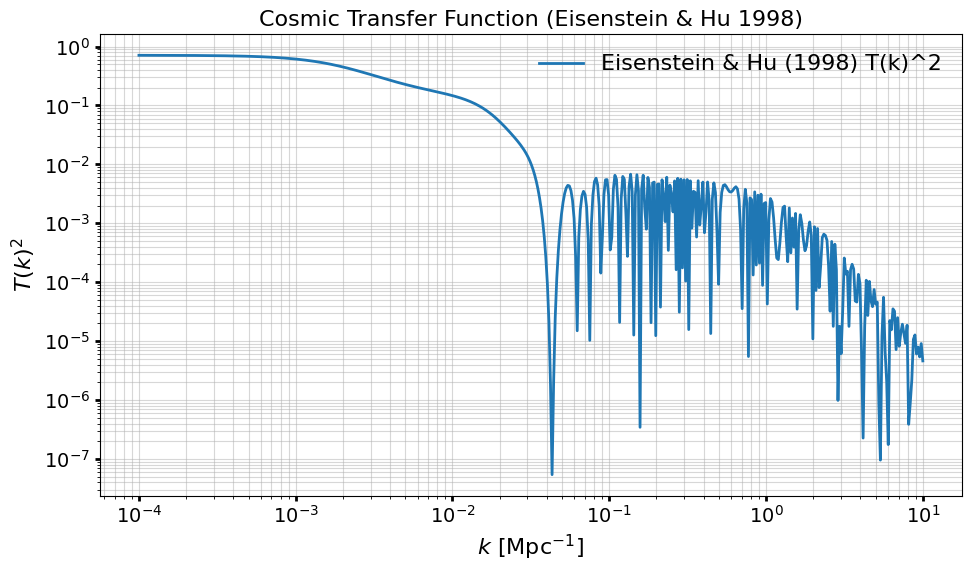

In [3]:
h = 0.675
Omega_m = 0.31
Omega_b = 0.0487
# sigma_8 and n_s are for power spectrum normalization/tilt, not transfer function shape
# sigma_8 = 0.83
# n_s = 0.96

# Wavenumbers (k) in 1/Mpc
k_values = np.logspace(-4, 1, 500) # From 10^-4 to 10^1 Mpc^-1

# Calculate the transfer function
T_k_eh98 = eh98_transfer_function(k_values, h, Omega_m, Omega_b)

print(f"Calculated transfer function for k = {k_values[0]:.2e} 1/Mpc: T(k) = {T_k_eh98[0]:.4f}")
print(f"Calculated transfer function for k = {k_values[100]:.2e} 1/Mpc: T(k) = {T_k_eh98[100]:.4f}")
print(f"Calculated transfer function for k = {k_values[-1]:.2e} 1/Mpc: T(k) = {T_k_eh98[-1]:.4f}")

# Plotting the transfer function
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    plt.loglog(k_values, T_k_eh98**2, label='Eisenstein & Hu (1998) T(k)^2') # Often T(k)^2 is plotted for P(k)
    plt.xlabel(r'$k \ [\mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$T(k)^2$')
    plt.title('Cosmic Transfer Function (Eisenstein & Hu 1998)')
    plt.grid(True, which="both", ls="-")
    plt.legend()
    plt.show()

except ImportError:
    print("\nMatplotlib not found. Skipping plot.")
    print("To plot the transfer function, please install matplotlib: pip install matplotlib")

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import camb

# 1. Define Cosmological Parameters
# ---------------------------------
# User-specified cosmological parameters
h = 0.675
Omega_m = 0.31
Omega_b = 0.0487
sigma_8 = 0.83
n_s = 0.96

# Calculate derived parameters required by CAMB
# CAMB typically takes omega_b * h^2 and omega_c * h^2
ombh2 = Omega_b * h**2
Omega_c = Omega_m - Omega_b  # Dark matter density parameter
omch2 = Omega_c * h**2

print(f"Cosmological Parameters:")
print(f"  h = {h}")
print(f"  Omega_m = {Omega_m}")
print(f"  Omega_b = {Omega_b}")
print(f"  sigma_8 = {sigma_8}")
print(f"  n_s = {n_s}")
print(f"\nDerived CAMB Parameters:")
print(f"  ombh2 (Omega_b * h^2) = {ombh2:.4f}")
print(f"  omch2 (Omega_c * h^2) = {omch2:.4f}")
print(f"  H0 = {h * 100} km/s/Mpc")


# 2. Set up CAMB Parameters
# -------------------------
# Create a CAMBparams object
pars = camb.CAMBparams()

# Set the cosmological parameters
pars.set_cosmology(
    H0=h * 100,  # H_0 in km/s/Mpc
    ombh2=ombh2,
    omch2=omch2,
    ns=n_s,
    # There are other parameters you might want to set, e.g., for massive neutrinos,
    # but for a standard LCDM, these are often sufficient.
    # For now, we assume massless neutrinos and flat geometry.
    # CAMB defaults: OmK=0 (flat), YHe=0.246 (default helium frac), num_nu_massless=3.046
)

# Set sigma_8 for normalization
# CAMB can normalize to sigma8 at z=0 directly.
pars.set_matter_power(
    redshifts=[0.],  # Calculate power spectrum at z=0
    kmax=1.0 # Maximum k for power spectrum output
)
pars.NonLinear = camb.model.NonLinear_none # Linear power spectrum
pars.set_sigma8(sigma_8)


# Specify that we want transfer functions
# CAMB needs to be told explicitly to compute transfer functions
pars.WantTransfer = True
# Set the k-range for the transfer functions
# k_min (h/Mpc), k_max (h/Mpc), number of points
pars.set_accuracy(AccuracyBoost=2) # Boost accuracy for smoother transfer functions if needed
pars.set_for_lmax(2500, lens_potential_accuracy=0) # Required to ensure all relevant scales are covered

# 3. Run CAMB to get results
# --------------------------
# Get CAMB results object
results = camb.get_results(pars)

# 4. Extract the Transfer Function
# --------------------------------
# Get matter transfer data at z=0 (the redshift we set above)
# The transfer_data object contains k values and different transfer functions (CDM, baryons, photons, neutrinos, total)
# transfer_data.transfer_data[0] are k values
# transfer_data.transfer_data[1] is CDM transfer function
# transfer_data.transfer_data[2] is Baryon transfer function
# transfer_data.transfer_data[5] is Total Matter transfer function (CDM+baryons)
transfer_data = results.get_matter_transfer_data()

k = transfer_data.transfer_data[0]
transfer_function = transfer_data.transfer_data[5] # Total matter transfer function

# 5. Plot the Transfer Function
# -----------------------------
plt.figure(figsize=(10, 6))
plt.loglog(k, transfer_function, label='Total Matter Transfer Function')
plt.xlabel(r'$k \text{ [h/Mpc]}$')
plt.ylabel(r'$T(k)$')
plt.title('Cosmic Matter Transfer Function')
plt.grid(True, which="both", ls="-")
plt.legend()
plt.tight_layout()
plt.show()

print("\nTransfer function calculated and plotted successfully.")
print(f"Range of k values: [{k.min():.2e}, {k.max():.2e}] h/Mpc")

Cosmological Parameters:
  h = 0.675
  Omega_m = 0.31
  Omega_b = 0.0487
  sigma_8 = 0.83
  n_s = 0.96

Derived CAMB Parameters:
  ombh2 (Omega_b * h^2) = 0.0222
  omch2 (Omega_c * h^2) = 0.1191
  H0 = 67.5 km/s/Mpc


TypeError: CAMBparams.set_cosmology() got an unexpected keyword argument 'ns'

Saved cmb_CAMB.tf with 2156 rows.


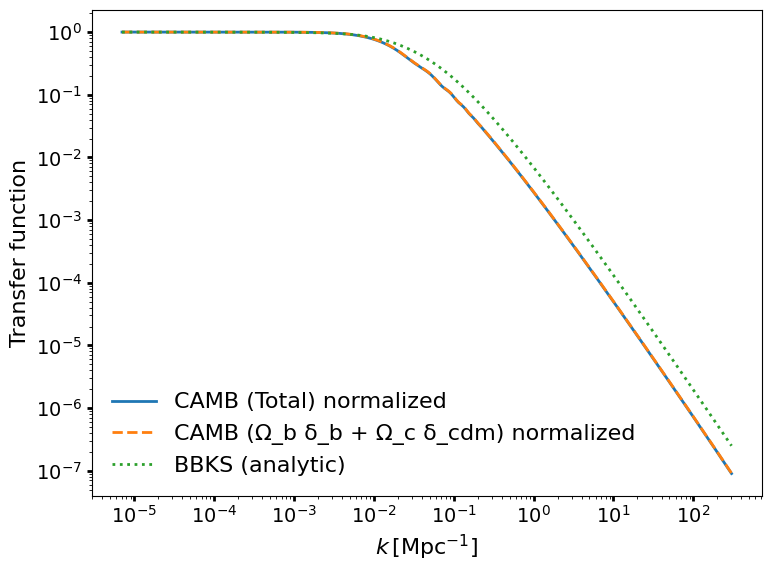

In [6]:
# ==========================================
# CAMB → CosmicIC transfer function generator
# Includes CAMB δ_tot, BBKS, and CosmicIC-style T(k)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import camb
from camb import model, initialpower

# --------------------------------------------------
# 1. Cosmological parameters
# --------------------------------------------------
h        = 0.675
Omega_b  = 0.0487
Omega_c  = 0.31 - Omega_b
Omega_m  = Omega_b + Omega_c
n_s      = 0.96
z_ic     = 200.0

# --------------------------------------------------
# 2. Set CAMB parameters
# --------------------------------------------------
pars = camb.CAMBparams()

pars.set_cosmology(
    H0     = 100*h,
    ombh2  = Omega_b*h*h,
    omch2  = Omega_c*h*h,
)

# Primordial spectrum (σ8 is derived from As)
pars.InitPower.set_params(ns=n_s)

pars.set_matter_power(
    redshifts=[z_ic],
    kmax=300.0      # physical Mpc^-1
)

pars.WantTransfer = True
pars.DoLensing = False

pars.Transfer.k_per_logint = 300  # default is ~10

# --------------------------------------------------
# 3. Run CAMB
# --------------------------------------------------
results   = camb.get_results(pars)
transfers = results.get_matter_transfer_data()

# --------------------------------------------------
# 4. Extract k and δ_i(k,z)
# --------------------------------------------------
k = transfers.q   # physical Mpc^-1 units

delta_cdm = transfers.transfer_z('delta_cdm',    z_index=0)
delta_b   = transfers.transfer_z('delta_baryon', z_index=0)
delta_m   = transfers.transfer_z('delta_tot',    z_index=0)

# CAMB already has δ(k→0)=1

# --------------------------------------------------
# 5. Generate CosmicIC 7-column format
# --------------------------------------------------
zeros = np.zeros_like(k)
cmb_tf = np.column_stack([
    k, delta_cdm, delta_b, zeros, zeros, zeros, zeros
])

np.savetxt("cmb_CAMB.tf", cmb_tf, fmt="%.10e")
print(f"Saved cmb_CAMB.tf with {len(k)} rows.")

# --------------------------------------------------
# 6. BBKS transfer function
# --------------------------------------------------
def T_BBKS(k, Omega_m, h):
    q = k / (Omega_m * h)
    return (
        np.log(1 + 2.34*q)/(2.34*q) *
        (1 + 3.89*q + (16.1*q)**2 + (5.46*q)**3 + (6.71*q)**4)**(-0.25)
    )

T_bbks = T_BBKS(k, Omega_m, h)

# --------------------------------------------------
# 7. CosmicIC-style matter transfer
# --------------------------------------------------
f_b = Omega_b / Omega_m
f_c = Omega_c / Omega_m

T_cic = f_b * delta_b + f_c * delta_cdm     # unnormalized
T_cic_norm = T_cic / T_cic[0]               # normalized like CosmicIC would do internally

# --------------------------------------------------
# 8. CAMB normalized
# --------------------------------------------------
T_camb_norm = delta_m / delta_m[0]

# --------------------------------------------------
# 9. Plot all comparisons
# --------------------------------------------------
plt.figure(figsize=(8,6))

plt.loglog(k, T_camb_norm,     label="CAMB (Total) normalized")
plt.loglog(k, T_cic_norm, '--',label="CAMB (Ω_b δ_b + Ω_c δ_cdm) normalized")
plt.loglog(k, T_bbks,   ':',   label="BBKS (analytic)")

plt.xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel("Transfer function")
plt.legend()
plt.tight_layout()
plt.savefig("CAMB_CIC_BBKS_comparison.png", dpi=300)
plt.show()
